In [31]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam

# 1. تحميل البيانات
print("Downloading real-time data...")
df = yf.download("BTC-USD", period="1y")

# 2. استخراج سعر الإغلاق وتنظيفه
close_prices = df[['Close']].dropna()
raw_prices = close_prices.values

# 3. Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(raw_prices)

# 4. تجهيز البيانات
prediction_days = 60
x = []
y = []

for i in range(prediction_days, len(scaled_data)):
    x.append(scaled_data[i - prediction_days:i, 0])
    y.append(scaled_data[i, 0])

x = np.array(x)
y = np.array(y)

# التأكد من الشكل الصحيح
x = np.reshape(x, (x.shape[0], x.shape[1], 1))

# 5. بناء الموديل
model = Sequential()

model.add(LSTM(units=64, return_sequences=True, input_shape=(x.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=1))

# 6. Optimizer
opt = Adam(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=opt, loss='mean_squared_error')

# 7. التدريب
model.fit(x, y, epochs=50, batch_size=32)

/tmp/ipykernel_11554/673551878.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", period="1y")
[*********************100%***********************]  1 of 1 completed


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0937
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0216
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0134
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0124
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0098
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0084
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0090
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0075
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0088
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0085
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0076
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0073
Epoch 13/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0078
Epoch 14/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0075
Epoch 15/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0080
Epoc

In [32]:
test_start = "2026-01-01"
test_end = "2026-03-26" #بيناتات حديثة
test_data = yf.download("BTC-USD", start=test_start, end=test_end)

actual_prices = test_data['Close'].values

total_dataset = pd.concat((df['Close'], test_data['Close']), axis=0)

model_inputs = total_dataset[len(total_dataset) - len(test_data) - 60:].values

model_inputs = pd.DataFrame(model_inputs, columns=['Close']).ffill().values

#scaler to put the data in one column
model_inputs = model_inputs.reshape(-1, 1)
#scaling
model_inputs = scaler.transform(model_inputs)

x_test = []
for i in range(60, len(model_inputs)):
  x_test.append(model_inputs[i-60:i, 0])

#transform to array
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted_prices)

/tmp/ipykernel_11554/2047803904.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_data = yf.download("BTC-USD", start=test_start, end=test_end)
[*********************100%***********************]  1 of 1 completed


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


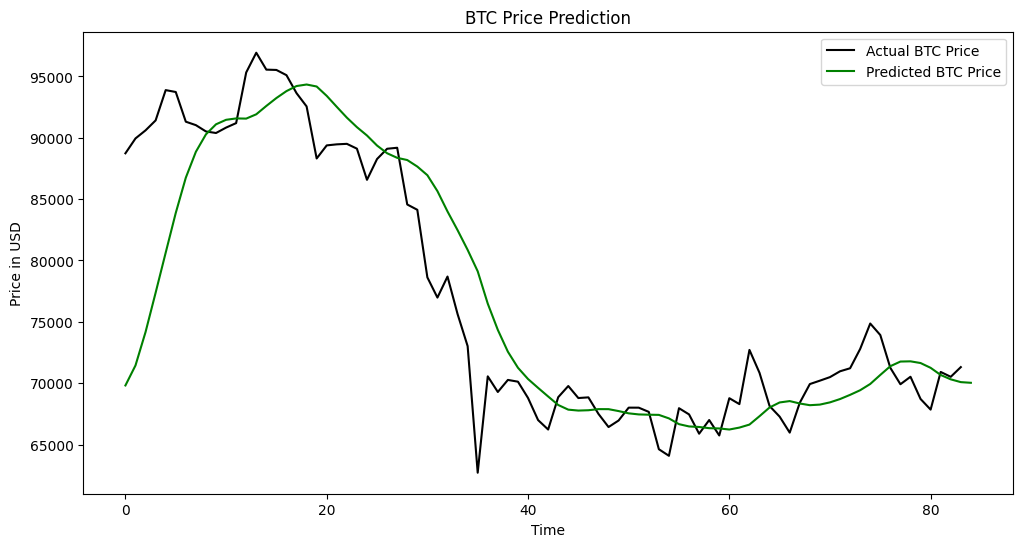

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(actual_prices, color="black", label="Actual BTC Price")
plt.plot(predicted_prices, color="green", label="Predicted BTC Price")
plt.title("BTC Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price in USD")
plt.legend()
plt.show()

In [34]:
# توقع السعر لليوم الجديد
last_60_days = model_inputs[-60:].reshape(1, 60, 1)
next_day_pred = model.predict(last_60_days)
next_day_price = scaler.inverse_transform(next_day_pred)

print(f"السعر المتوقع: {next_day_price[0][0]:.2f} $")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
السعر المتوقع: 70082.91 $


In [35]:
model.save('btc_lstm_model.h5')